# GWAS on Diseased donors — WGS data

Same analysis as `metric_corr_with_GWAS_only_diseased_XDP.ipynb`, split into prep + run
(mirrors the GSA split: `GSA_XDP_01_prepare_for_GWAS.ipynb` / `GSA_XDP_02_run_GWAS.ipynb`).
The genotype-side prep (candidate-region VCF, ancestry PCA, kinship) is done by
[`WGS_XDP_01_prepare_for_GWAS.ipynb`](WGS_XDP_01_prepare_for_GWAS.ipynb) — this notebook
picks up from its outputs (`subset/candidate.norm.bcf`, `whole_xdp_PCA/PCA.eigenvec`) and
computes the phenotype + runs the regression.

trait ~ allele_dosage + PCs + sex + Age + d1d2_z2_cov


## Load snRNA-seq data and select cell types

In [51]:
import scanpy as sc
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [52]:
# Per donor, per cell type 32i ratio calcualted in other notebook

df_32i_per_donor = pd.read_csv(
    f"/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/32i/32i_per_donor_Striatum.csv"
)

# Select ony matrix ratio (matrix degenrte well, so ratio is a good proxy)
CT_RATIO = "Patch"
df_32i_per_donor = df_32i_per_donor[df_32i_per_donor["ct_for_deg"] == CT_RATIO]

print("number of donors in 32i_per_donor:", df_32i_per_donor.shape[0])
df_32i_per_donor

number of donors in 32i_per_donor: 47


,donor_id,n_pre_umis,n_post_umis,condition,pileup_metric,pre_density,post_density,pileup_metric_norm,ct_for_deg,ct
47,PCMC-16-011,9.0,26.0,XDP,0.257143,0.000590,0.002197,0.211644,Patch,Neuron
48,PCMC-16-012,24.0,39.0,XDP,0.380952,0.001573,0.003295,0.323074,Patch,Neuron
49,SCF-18-003,33.0,35.0,XDP,0.485294,0.002163,0.002957,0.422379,Patch,Neuron
50,SCF-18-004,15.0,24.0,XDP,0.384615,0.000983,0.002028,0.326474,Patch,Neuron
51,SCF-18-006,60.0,101.0,XDP,0.372671,0.003932,0.008534,0.315409,Patch,Neuron
52,SCF-19-009,14.0,40.0,XDP,0.259259,0.000917,0.003380,0.213493,Patch,Neuron
53,SCF-19-014,33.0,66.0,XDP,0.333333,0.002163,0.005577,0.279424,Patch,Neuron
54,SCF-19-018,26.0,27.0,XDP,0.490566,0.001704,0.002281,0.427535,Patch,Neuron
55,SCF-19-020,233.0,247.0,XDP,0.485417,0.015269,0.020870,0.422499,Patch,Neuron
56,SCF-20-023,38.0,60.0,XDP,0.387755,0.002490,0.005070,0.329393,Patch,Neuron


In [53]:
df_meta = pd.read_csv("/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/original_data/XDP dataset metadata - Gabri's Version.csv")
df_meta = df_meta.drop(columns=["from_where_this_info_comes_from",])

print("number of donors in df_meta:", df_meta.shape[0])

number of donors in df_meta: 47


In [54]:
df_32i_per_donor = df_32i_per_donor.merge(df_meta, how="left", left_on="donor_id", right_on="donor_id")

print("number of donors in df_32i_per_donor:", df_32i_per_donor.groupby("donor_id").ngroups)
df_32i_per_donor

number of donors in df_32i_per_donor: 47


,donor_id,n_pre_umis,n_post_umis,condition,pileup_metric,pre_density,post_density,pileup_metric_norm,ct_for_deg,ct,...,pH,Brain_bank,Year_collected,repeat_length,repeat_length_notes,Age_of_Onset,Age_of_Death,Disease_duration,CAP,immediate_cause_of_death
0,PCMC-16-011,9.0,26.0,XDP,0.257143,0.000590,0.002197,0.211644,Patch,Neuron,...,6.0,PCMC,2016,35,NaN,53,55,2,70.0,Dystonia
1,PCMC-16-012,24.0,39.0,XDP,0.380952,0.001573,0.003295,0.323074,Patch,Neuron,...,6.4,PCMC,2016,41,NaN,34,41,7,287.0,Dystonia
2,SCF-18-003,33.0,35.0,XDP,0.485294,0.002163,0.002957,0.422379,Patch,Neuron,...,6.4,SCF,2018,42,NaN,32,41,9,378.0,"Pnuemonia, Dystonia"
3,SCF-18-004,15.0,24.0,XDP,0.384615,0.000983,0.002028,0.326474,Patch,Neuron,...,6.0,SCF,2018,41,NaN,41,56,15,615.0,Pnuemonia
4,SCF-18-006,60.0,101.0,XDP,0.372671,0.003932,0.008534,0.315409,Patch,Neuron,...,6.2,SCF,2018,35,NaN,46,51,5,175.0,Dystonia
5,SCF-19-009,14.0,40.0,XDP,0.259259,0.000917,0.003380,0.213493,Patch,Neuron,...,6.0,SCF,2019,39,NaN,49,54,5,195.0,Pnuemonia
6,SCF-19-014,33.0,66.0,XDP,0.333333,0.002163,0.005577,0.279424,Patch,Neuron,...,6.2,SCF,2019,50,NaN,30,32,2,100.0,Aspiration Pnuemonia
7,SCF-19-018,26.0,27.0,XDP,0.490566,0.001704,0.002281,0.427535,Patch,Neuron,...,6.0,SCF,2019,45,NaN,33,40,7,315.0,Dystonia
8,SCF-19-020,233.0,247.0,XDP,0.485417,0.015269,0.020870,0.422499,Patch,Neuron,...,6.2,SCF,2019,43,NaN,36,51,15,645.0,Dystonia
9,SCF-20-023,38.0,60.0,XDP,0.387755,0.002490,0.005070,0.329393,Patch,Neuron,...,6.0,SCF,2020,44,"42, 46 (mosaic)",38,41,3,132.0,Myocardial Infraction


### Filter to Diseased + Male donors for GWAS

number of donors in df_meta_diseased: 29


,donor_id,n_pre_umis,n_post_umis,condition,pileup_metric,pre_density,post_density,pileup_metric_norm,ct_for_deg,ct,...,pH,Brain_bank,Year_collected,repeat_length,repeat_length_notes,Age_of_Onset,Age_of_Death,Disease_duration,CAP,immediate_cause_of_death
1,PCMC-16-012,24.0,39.0,XDP,0.380952,0.001573,0.003295,0.323074,Patch,Neuron,...,6.4,PCMC,2016,41,NaN,34,41,7,287.0,Dystonia
2,SCF-18-003,33.0,35.0,XDP,0.485294,0.002163,0.002957,0.422379,Patch,Neuron,...,6.4,SCF,2018,42,NaN,32,41,9,378.0,"Pnuemonia, Dystonia"
3,SCF-18-004,15.0,24.0,XDP,0.384615,0.000983,0.002028,0.326474,Patch,Neuron,...,6.0,SCF,2018,41,NaN,41,56,15,615.0,Pnuemonia
4,SCF-18-006,60.0,101.0,XDP,0.372671,0.003932,0.008534,0.315409,Patch,Neuron,...,6.2,SCF,2018,35,NaN,46,51,5,175.0,Dystonia
5,SCF-19-009,14.0,40.0,XDP,0.259259,0.000917,0.003380,0.213493,Patch,Neuron,...,6.0,SCF,2019,39,NaN,49,54,5,195.0,Pnuemonia
6,SCF-19-014,33.0,66.0,XDP,0.333333,0.002163,0.005577,0.279424,Patch,Neuron,...,6.2,SCF,2019,50,NaN,30,32,2,100.0,Aspiration Pnuemonia
7,SCF-19-018,26.0,27.0,XDP,0.490566,0.001704,0.002281,0.427535,Patch,Neuron,...,6.0,SCF,2019,45,NaN,33,40,7,315.0,Dystonia
8,SCF-19-020,233.0,247.0,XDP,0.485417,0.015269,0.020870,0.422499,Patch,Neuron,...,6.2,SCF,2019,43,NaN,36,51,15,645.0,Dystonia
9,SCF-20-023,38.0,60.0,XDP,0.387755,0.002490,0.005070,0.329393,Patch,Neuron,...,6.0,SCF,2020,44,"42, 46 (mosaic)",38,41,3,132.0,Myocardial Infraction
10,SCF-20-024,67.0,113.0,XDP,0.372222,0.004391,0.009548,0.314995,Patch,Neuron,...,NaN,SCF,2020,46,NaN,39,46,7,322.0,Probable Myocardial Infarction


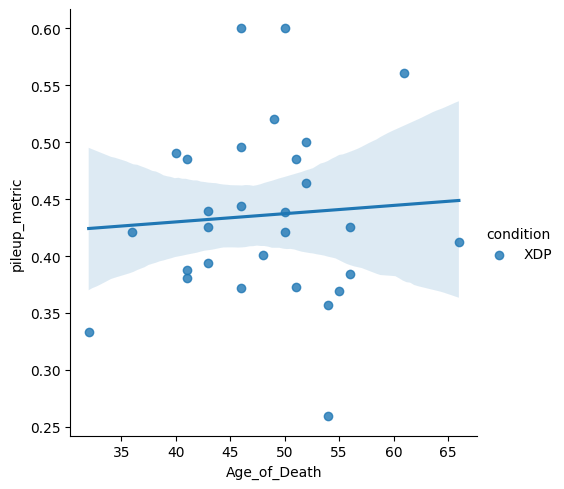

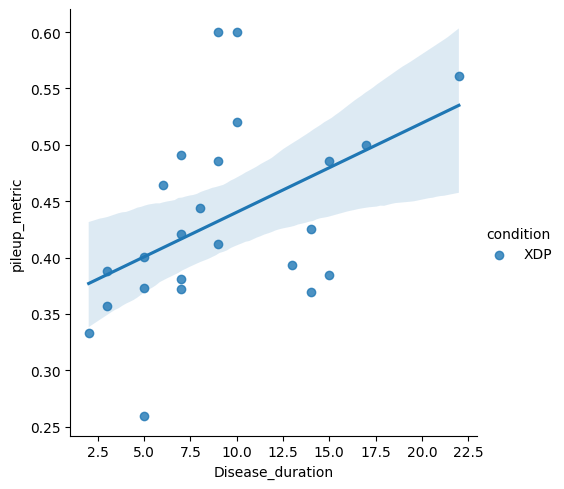

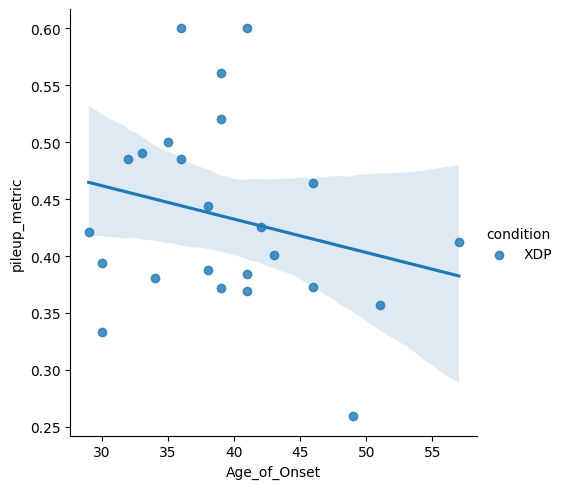

In [55]:
df_meta_diseased = df_32i_per_donor[
        (df_32i_per_donor["condition"] == "XDP") &
        (df_32i_per_donor["Sex"] == "M")
        ].copy()
print("number of donors in df_meta_diseased:", df_meta_diseased.groupby("donor_id").ngroups)

display(df_meta_diseased)


for cov in ["Age_of_Death", "Disease_duration", "Age_of_Onset"]:
    df_plot = df_meta_diseased.copy()
    df_plot[cov] = pd.to_numeric(df_plot[cov], errors="coerce")  # coerce non-numeric strings (e.g. "not_applicable") to NaN
    sns.lmplot(
        data=df_plot.dropna(subset=[cov, "pileup_metric"]),
        x=cov,
        y="pileup_metric",
        hue="condition",
    )


## WGS genotype inputs

Everything up to this point is identical to the monolithic notebook. From here on, instead of
rebuilding the candidate-region VCF and ancestry PCA from scratch (contig check, gene BED
lookup, donor-ID intersection, chrom rename, `bcftools norm`, PCA, kinship), we load the
already-prepared WGS outputs directly from
[`WGS_XDP_01_prepare_for_GWAS.ipynb`](WGS_XDP_01_prepare_for_GWAS.ipynb):

- `subset/candidate.norm.bcf` — candidate-region (`MSH3`, `PMS2`) genotypes, already subset to
  the male+XDP donors matched to the VCF, chromosome-renamed, and normalized.
- `whole_xdp_PCA/PCA.eigenvec` — ancestry PCs, computed on the full WGS cohort.


In [56]:
import subprocess, os

VCF_FOLDER = "/home/gdallagl/myworkdir/XDP/data/XDP/vcf"
MOUNT = VCF_FOLDER

IMAGE_BCFTOOLS = "quay.io/biocontainers/bcftools:1.21--h8b25389_0"
IMAGE_PLINK    = "quay.io/biocontainers/plink2:2.0.0a.6.9--h9948957_0"
N_THREADS = 16

def bcftools(args, check=True):
    cmd = ["podman", "run", "--rm", "-w", "/data", "-v", f"{MOUNT}:/data", IMAGE_BCFTOOLS, "bcftools", *args]
    p = subprocess.run(cmd, capture_output=True, text=True)
    if check and p.returncode != 0:
        raise RuntimeError(f"bcftools {' '.join(args)} failed:\n{p.stderr}")
    return p.stdout, p.stderr

def plink2(args, check=True):
    cmd = ["podman", "run", "--rm", "-w", "/data", "-v", f"{MOUNT}:/data", IMAGE_PLINK, "plink2", *args]
    p = subprocess.run(cmd, capture_output=True, text=True)
    print(p.stdout[-2000:])
    if check and p.returncode != 0:
        raise RuntimeError(f"plink2 {' '.join(args)} failed:\n{p.stderr}")
    return p.stdout, p.stderr

SUBSET_NORM_VCF = "subset/candidate.norm.bcf"   # from WGS_XDP_01_prepare_for_GWAS.ipynb
PLINK_INFLAG    = "--bcf"
SUBSET_PGEN     = "subset/plink/candidate"

PCA_OUT = "whole_xdp_PCA/PCA"                    # from WGS_XDP_01_prepare_for_GWAS.ipynb

os.makedirs(f"{VCF_FOLDER}/subset/plink", exist_ok=True)
os.makedirs(f"{VCF_FOLDER}/subset/gwas_input_covs", exist_ok=True)
os.makedirs(f"{VCF_FOLDER}/subset/results", exist_ok=True)


### Convert candidate-region VCF to plink2 + QC

In [57]:
# 4a. Convert VCF/BCF to plink2 binary (.pgen / .pvar / .psam)
plink2([PLINK_INFLAG, SUBSET_NORM_VCF,
        "--set-all-var-ids", "@:#:$r:$a",             # assign a deterministic ID to every variant
        "--new-id-max-allele-len", "100", "missing",  # alleles longer than 100bp -> ID "missing"
        "--make-pgen", "--out", SUBSET_PGEN, "--threads", str(N_THREADS)])

# 4b. Quality-control the plink file
plink2(["--pfile", SUBSET_PGEN,
        "--geno", "0.05",   # remove variants missing in >5% of samples (unreliable calls)
        "--mind", "0.1",    # remove samples missing >10% of variants (poor sequencing)
        "--maf", "0.05",    # keep only common variants (MAF >= 5%)
        "--make-pgen", "--out", f"{SUBSET_PGEN}_qc", "--threads", str(N_THREADS)])


sing
  --out subset/plink/candidate
  --set-all-var-ids @:#:$r:$a
  --threads 16

Start time: Fri Aug  7 16:38:57 2026
314189 MiB RAM detected, ~241614 available; reserving 157094 MiB for main
workspace.
Using up to 16 threads (change this with --threads).

--bcf: 234 variants scanned.

--bcf: 0k variants converted.  
--bcf: subset/plink/candidate-temporary.pgen +
subset/plink/candidate-temporary.pvar.zst +
subset/plink/candidate-temporary.psam written.
13 samples (0 females, 0 males, 13 ambiguous; 13 founders) loaded from
subset/plink/candidate-temporary.psam.
234 variants loaded from subset/plink/candidate-temporary.pvar.zst.
Note: No phenotype data present.
Writing subset/plink/candidate.psam ... done.
Writing subset/plink/candidate.pvar ... 10101111121213131414151516161717181819192020212122222323242425252626272728282929303031313232333334343535363637373838393940404141424243434444454546464747484849505051515252535354545555565657575858595960606161626263636464656566666767686869697070717

('PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/\n(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3\nLogging to subset/plink/candidate_qc.log.\nOptions in effect:\n  --geno 0.05\n  --maf 0.05\n  --make-pgen\n  --mind 0.1\n  --out subset/plink/candidate_qc\n  --pfile subset/plink/candidate\n  --threads 16\n\nStart time: Fri Aug  7 16:38:58 2026\n314189 MiB RAM detected, ~241605 available; reserving 157094 MiB for main\nworkspace.\nUsing up to 16 threads (change this with --threads).\n13 samples (0 females, 0 males, 13 ambiguous; 13 founders) loaded from\nsubset/plink/candidate.psam.\n234 variants loaded from subset/plink/candidate.pvar.\nNote: No phenotype data present.\nCalculating sample missingness rates... 0%\x08\x08done.\n0 samples removed due to missing genotype data (--mind).\n13 samples (0 females, 0 males, 13 ambiguous; 13 founders) remaining after main\nfilters.\nCalculating allele frequencies... 0%\x08\x08done.\n--g

## Prepare GWAS Input Files

Merge the snRNA-seq trait, clinical covariates, and ancestry PCs, then write
two plain-text files that plink2 expects:

- **pheno.txt** — `IID  m1_z1_trait` (rank-normalised)
- **covar.txt** — `IID  d1d1_z2_cov  age  sex_num  PC1  PC2  PC3`

In [58]:
df_gwas = df_meta_diseased.copy()

# Encode sex as integer: plink2 convention = 1 male, 2 female
sex_map = {"M": 1, "male": 1, "F": 2, "female": 2}
df_gwas["sex_num"] = df_gwas["Sex"].map(sex_map)

# age_of_death is the only age variable always defined for all donors.
df_gwas["age"] = pd.to_numeric(df_gwas["Age_of_Death"], errors="coerce")

# # Merge ancestry PCs: IID in pcs matches donor_id in df_gwas via original_donor_id.
# df_gwas = df_gwas.merge(
#     pcs.set_index("IID")[["PC1", "PC2", "PC3"]],
#     left_on="original_donor_id",
#     right_index=True,
#     how="left"
# )

display(df_gwas)

# Drop any donor missing the trait, PCs, age, sex, or the cell-type covariate.
df_gwas = df_gwas.dropna(
    subset=["pileup_metric", "age", "sex_num"]#, "PC1"]
)

display(df_gwas)

# IID column must match VCF sample names exactly for plink to link files.
df_gwas["IID"] = df_gwas["original_donor_id"]

print(f"Final GWAS N = {len(df_gwas)} donors")
display(df_gwas[["IID","pileup_metric","age","sex_num"]])#,"PC1","PC2","PC3"]])

TRAIT     = "pileup_metric"
COVS      = ["age"] # "sex_num"] # "PC1", "PC2", "PC3"]
PHENO_FILE   = "subset/gwas_input_covs/pheno.txt"
COVAR_FILE   = "subset/gwas_input_covs/covar.txt"
RESULTS_FILE = "subset/results/results"

pheno = df_gwas[["IID", TRAIT]]
pheno.to_csv(f"{VCF_FOLDER}/{PHENO_FILE}", sep="\t", index=False, na_rep="NA")
print(f"\nPhenotype file written -> {PHENO_FILE}  ({len(pheno)} rows)")

covar = df_gwas[["IID"] + COVS]
covar.to_csv(f"{VCF_FOLDER}/{COVAR_FILE}", sep="\t", index=False, na_rep="NA")
print(f"Covariate file written  -> {COVAR_FILE}  (covariates: {COVS})")


,donor_id,n_pre_umis,n_post_umis,condition,pileup_metric,pre_density,post_density,pileup_metric_norm,ct_for_deg,ct,...,Year_collected,repeat_length,repeat_length_notes,Age_of_Onset,Age_of_Death,Disease_duration,CAP,immediate_cause_of_death,sex_num,age
1,PCMC-16-012,24.0,39.0,XDP,0.380952,0.001573,0.003295,0.323074,Patch,Neuron,...,2016,41,NaN,34,41,7,287.0,Dystonia,1,41
2,SCF-18-003,33.0,35.0,XDP,0.485294,0.002163,0.002957,0.422379,Patch,Neuron,...,2018,42,NaN,32,41,9,378.0,"Pnuemonia, Dystonia",1,41
3,SCF-18-004,15.0,24.0,XDP,0.384615,0.000983,0.002028,0.326474,Patch,Neuron,...,2018,41,NaN,41,56,15,615.0,Pnuemonia,1,56
4,SCF-18-006,60.0,101.0,XDP,0.372671,0.003932,0.008534,0.315409,Patch,Neuron,...,2018,35,NaN,46,51,5,175.0,Dystonia,1,51
5,SCF-19-009,14.0,40.0,XDP,0.259259,0.000917,0.003380,0.213493,Patch,Neuron,...,2019,39,NaN,49,54,5,195.0,Pnuemonia,1,54
6,SCF-19-014,33.0,66.0,XDP,0.333333,0.002163,0.005577,0.279424,Patch,Neuron,...,2019,50,NaN,30,32,2,100.0,Aspiration Pnuemonia,1,32
7,SCF-19-018,26.0,27.0,XDP,0.490566,0.001704,0.002281,0.427535,Patch,Neuron,...,2019,45,NaN,33,40,7,315.0,Dystonia,1,40
8,SCF-19-020,233.0,247.0,XDP,0.485417,0.015269,0.020870,0.422499,Patch,Neuron,...,2019,43,NaN,36,51,15,645.0,Dystonia,1,51
9,SCF-20-023,38.0,60.0,XDP,0.387755,0.002490,0.005070,0.329393,Patch,Neuron,...,2020,44,"42, 46 (mosaic)",38,41,3,132.0,Myocardial Infraction,1,41
10,SCF-20-024,67.0,113.0,XDP,0.372222,0.004391,0.009548,0.314995,Patch,Neuron,...,2020,46,NaN,39,46,7,322.0,Probable Myocardial Infarction,1,46


,donor_id,n_pre_umis,n_post_umis,condition,pileup_metric,pre_density,post_density,pileup_metric_norm,ct_for_deg,ct,...,Year_collected,repeat_length,repeat_length_notes,Age_of_Onset,Age_of_Death,Disease_duration,CAP,immediate_cause_of_death,sex_num,age
1,PCMC-16-012,24.0,39.0,XDP,0.380952,0.001573,0.003295,0.323074,Patch,Neuron,...,2016,41,NaN,34,41,7,287.0,Dystonia,1,41
2,SCF-18-003,33.0,35.0,XDP,0.485294,0.002163,0.002957,0.422379,Patch,Neuron,...,2018,42,NaN,32,41,9,378.0,"Pnuemonia, Dystonia",1,41
3,SCF-18-004,15.0,24.0,XDP,0.384615,0.000983,0.002028,0.326474,Patch,Neuron,...,2018,41,NaN,41,56,15,615.0,Pnuemonia,1,56
4,SCF-18-006,60.0,101.0,XDP,0.372671,0.003932,0.008534,0.315409,Patch,Neuron,...,2018,35,NaN,46,51,5,175.0,Dystonia,1,51
5,SCF-19-009,14.0,40.0,XDP,0.259259,0.000917,0.003380,0.213493,Patch,Neuron,...,2019,39,NaN,49,54,5,195.0,Pnuemonia,1,54
6,SCF-19-014,33.0,66.0,XDP,0.333333,0.002163,0.005577,0.279424,Patch,Neuron,...,2019,50,NaN,30,32,2,100.0,Aspiration Pnuemonia,1,32
7,SCF-19-018,26.0,27.0,XDP,0.490566,0.001704,0.002281,0.427535,Patch,Neuron,...,2019,45,NaN,33,40,7,315.0,Dystonia,1,40
8,SCF-19-020,233.0,247.0,XDP,0.485417,0.015269,0.020870,0.422499,Patch,Neuron,...,2019,43,NaN,36,51,15,645.0,Dystonia,1,51
9,SCF-20-023,38.0,60.0,XDP,0.387755,0.002490,0.005070,0.329393,Patch,Neuron,...,2020,44,"42, 46 (mosaic)",38,41,3,132.0,Myocardial Infraction,1,41
10,SCF-20-024,67.0,113.0,XDP,0.372222,0.004391,0.009548,0.314995,Patch,Neuron,...,2020,46,NaN,39,46,7,322.0,Probable Myocardial Infarction,1,46


Final GWAS N = 29 donors


,IID,pileup_metric,age,sex_num
1,PCMC-16-012,0.380952,41,1
2,SCF-18-003,0.485294,41,1
3,SCF-18-004,0.384615,56,1
4,SCF-18-006,0.372671,51,1
5,SCF-19-009,0.259259,54,1
6,SCF-19-014,0.333333,32,1
7,SCF-19-018,0.490566,40,1
8,SCF-19-020,0.485417,51,1
9,SCF-20-023,0.387755,41,1
10,SCF_20-024,0.372222,46,1



Phenotype file written -> subset/gwas_input_covs/pheno.txt  (29 rows)
Covariate file written  -> subset/gwas_input_covs/covar.txt  (covariates: ['age'])


### Run Linear GWAS

For every variant in the QC-filtered candidate region, plink2 fits:

```
m1_z1_trait ~ ALT_dosage + age 
```

- `ALT_dosage` is the additive genotype (0/1/2 copies of the ALT allele)
- Trait is rank-normalised -> residuals are approximately Normal (OLS valid)
- `--covar-variance-standardize` z-scores covariates so BETAs are on comparable scales

In [59]:
plink2(["--pfile", f"{SUBSET_PGEN}_qc",
        "--pheno", PHENO_FILE, "--pheno-name", TRAIT,
        "--covar", COVAR_FILE, "--covar-name", ",".join(COVS),
        "--glm", "hide-covar",              # OLS per variant; hide-covar drops covariate rows
        "--covar-variance-standardize",     # z-score all covariates before fitting
        "--out", RESULTS_FILE])


PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to subset/results/results.log.
Options in effect:
  --covar subset/gwas_input_covs/covar.txt
  --covar-name age
  --covar-variance-standardize
  --glm hide-covar
  --out subset/results/results
  --pfile subset/plink/candidate_qc
  --pheno subset/gwas_input_covs/pheno.txt
  --pheno-name pileup_metric

Start time: Fri Aug  7 16:38:58 2026
314189 MiB RAM detected, ~241610 available; reserving 157094 MiB for main
workspace.
Using up to 48 threads (change this with --threads).
13 samples (0 females, 0 males, 13 ambiguous; 13 founders) loaded from
subset/plink/candidate_qc.psam.
177 variants loaded from subset/plink/candidate_qc.pvar.
1 quantitative phenotype loaded (13 values).
1 covariate loaded from subset/gwas_input_covs/covar.txt.
--covar-variance-standardize: 1 covariate transformed.
Calculating allele frequencies... done.

("PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/\n(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3\nLogging to subset/results/results.log.\nOptions in effect:\n  --covar subset/gwas_input_covs/covar.txt\n  --covar-name age\n  --covar-variance-standardize\n  --glm hide-covar\n  --out subset/results/results\n  --pfile subset/plink/candidate_qc\n  --pheno subset/gwas_input_covs/pheno.txt\n  --pheno-name pileup_metric\n\nStart time: Fri Aug  7 16:38:58 2026\n314189 MiB RAM detected, ~241610 available; reserving 157094 MiB for main\nworkspace.\nUsing up to 48 threads (change this with --threads).\n13 samples (0 females, 0 males, 13 ambiguous; 13 founders) loaded from\nsubset/plink/candidate_qc.psam.\n177 variants loaded from subset/plink/candidate_qc.pvar.\n1 quantitative phenotype loaded (13 values).\n1 covariate loaded from subset/gwas_input_covs/covar.txt.\n--covar-variance-standardize: 1 covariate transformed.\nCalculating al

### Load, filter, and visualise GWAS results

Total variants tested: 177
Testable variants (MAF > 10%, non-NaN p): 177

Top 10 associations:


,#CHROM,POS,ID,REF,ALT,PROVISIONAL_REF?,A1,OMITTED,A1_FREQ,TEST,OBS_CT,BETA,SE,T_STAT,P,ERRCODE
24,5,80677376,5:80677376:T:C,T,C,N,T,C,0.423077,ADD,13,0.057179,0.024446,2.33895,0.041414,.
171,7,6020169,7:6020169:C:T,C,T,N,T,C,0.384615,ADD,13,0.038927,0.023770,1.63762,0.132542,.
173,7,6020816,7:6020816:G:A,G,A,N,A,G,0.384615,ADD,13,0.038927,0.023770,1.63762,0.132542,.
174,7,6020987,7:6020987:A:C,A,C,N,A,C,0.384615,ADD,13,0.038927,0.023770,1.63762,0.132542,.
169,7,6016899,7:6016899:G:A,G,A,N,A,G,0.384615,ADD,13,0.038927,0.023770,1.63762,0.132542,.
142,7,5988850,7:5988850:TTTTG:T,TTTTG,T,N,T,TTTTG,0.384615,ADD,13,0.038927,0.023770,1.63762,0.132542,.
170,7,6017313,7:6017313:C:T,C,T,N,T,C,0.384615,ADD,13,0.038927,0.023770,1.63762,0.132542,.
63,5,80725214,5:80725214:CA:C,CA,C,N,C,CA,0.500000,ADD,13,-0.044240,0.030395,-1.45550,0.176193,.
50,5,80710739,5:80710739:C:T,C,T,N,T,C,0.500000,ADD,13,-0.044240,0.030395,-1.45550,0.176193,.
66,5,80725626,5:80725626:A:C,A,C,N,C,A,0.500000,ADD,13,-0.044240,0.030395,-1.45550,0.176193,.


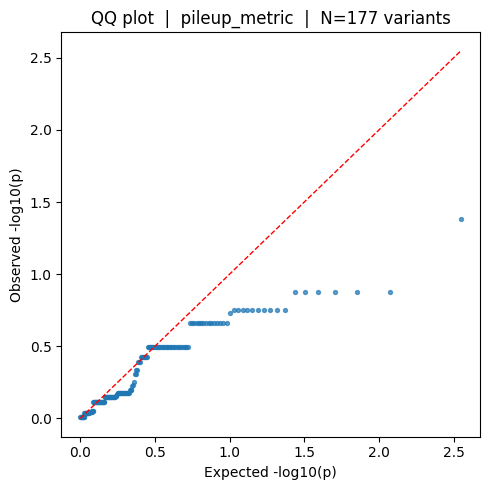

In [60]:
# Columns: #CHROM POS ID REF ALT A1 A1_FREQ TEST OBS_CT BETA SE T_STAT P ERRCODE
res = pd.read_csv(
    f"{VCF_FOLDER}/{RESULTS_FILE}.{TRAIT}.glm.linear", sep="\t"
)
print(f"Total variants tested: {len(res)}")

# Keep only testable variants: MAF > 10% (rare variants are unreliable with small N),
# and non-NaN p (NaN = monomorphic or collinear with a covariate).
testable = res[
    (res["A1_FREQ"] > 0.10) & (res["A1_FREQ"] < 0.90) & res["P"].notna()
].copy()
print(f"Testable variants (MAF > 10%, non-NaN p): {len(testable)}")

print("\nTop 10 associations:")
display(testable.sort_values("P").head(10))

# QQ plot: observed vs expected -log10(p) under the null (uniform)
p_vals   = testable["P"].sort_values().values
n        = len(p_vals)
expected = -np.log10((np.arange(1, n + 1) - 0.5) / n)
observed = -np.log10(p_vals)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(expected, observed, s=8, alpha=0.7)
ax.plot([0, expected.max()], [0, expected.max()], "r--", lw=1)
ax.set_xlabel("Expected -log10(p)")
ax.set_ylabel("Observed -log10(p)")
ax.set_title(f"QQ plot  |  {TRAIT}  |  N={n} variants")
plt.tight_layout(); plt.show()
